## Breast Cancer Prediction using Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [2]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

### Model Evaluation

In [4]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### Confusion Matrix

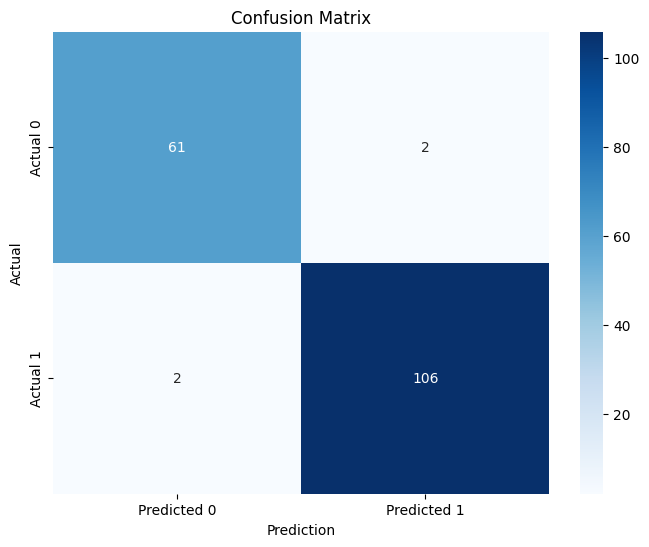

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

### ROC Curve

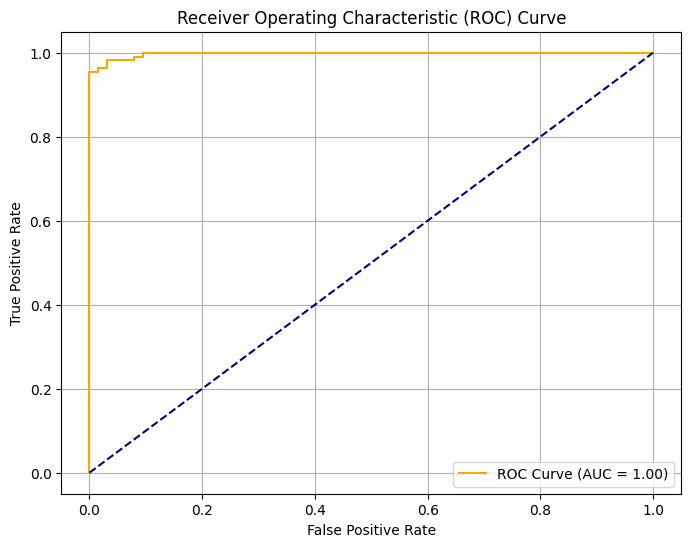

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Feature Coefficients (Importance)

/tmp/ipykernel_20874/1243584742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.values, y=coefficients.index, palette='viridis')


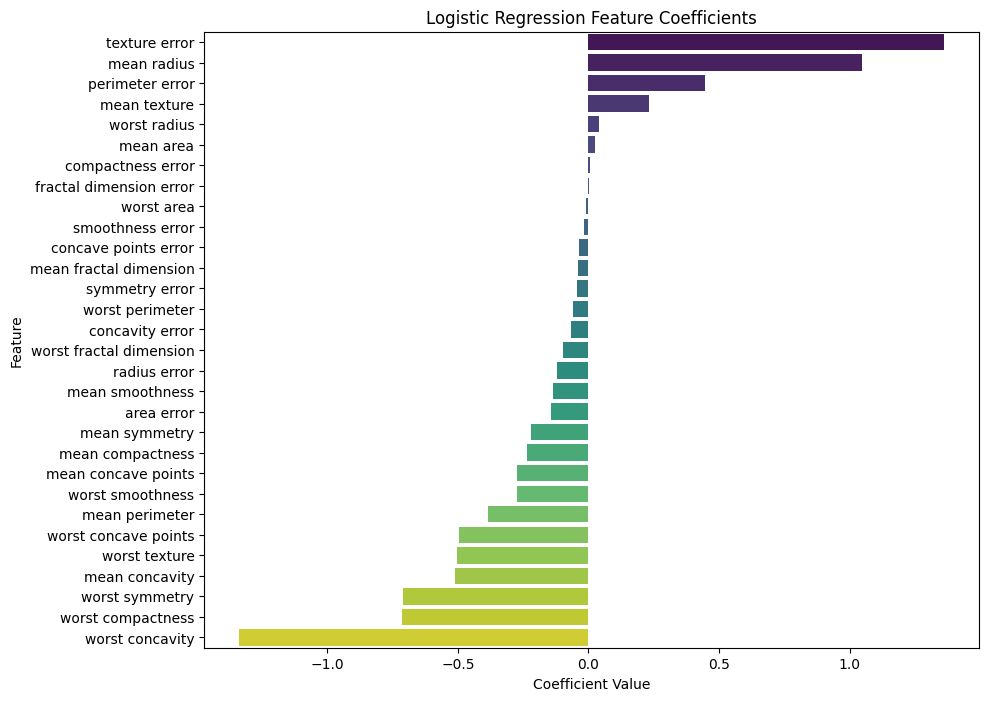

In [9]:
coefficients = pd.Series(model.coef_[0], index=X.columns)
coefficients = coefficients.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=coefficients.values, y=coefficients.index, palette='viridis')
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

### Test with New Data and Get Probabilities

In [10]:
sample_data_1 = X.mean().values.reshape(1, -1)
sample_data_2 = X.mean().values.reshape(1, -1)
sample_data_2[0, X.columns.get_loc('mean radius')] = X['mean radius'].max() * 0.9
sample_data_2[0, X.columns.get_loc('worst texture')] = X['worst texture'].min() * 0.5
sample_df = pd.DataFrame(np.vstack([sample_data_1, sample_data_2]), columns=X.columns)
display(sample_df)

probabilities = model.predict_proba(sample_df)

print("\nPredicted Probabilities for New Samples:")
for i, prob in enumerate(probabilities):
    print(f"Sample {i+1}: Class 0 (Benign) Probability: {prob[0]:.4f}, Class 1 (Malignant) Probability: {prob[1]:.4f}")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,14.127292,19.289649,91.969033,654.889104,0.09636,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.26919,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
1,25.299000,19.289649,91.969033,654.889104,0.09636,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.26919,6.010000,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946



Predicted Probabilities for New Samples:
Sample 1: Class 0 (Benign) Probability: 0.6118, Class 1 (Malignant) Probability: 0.3882
Sample 2: Class 0 (Benign) Probability: 0.0000, Class 1 (Malignant) Probability: 1.0000
